In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='white', font_scale=2, palette=sns.color_palette('Set2'),)
import matplotlib.pyplot as plt
import sqlalchemy as sa
import marimo as mo
import seaborn as sns
import lightning.pytorch
import polars as pl
from tqdm import tqdm

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
# with hydra.initialize(version_base=utils.HYDRA_INIT['version_base'], config_path='../conf'):
#     cfg = hydra.compose(utils.HYDRA_INIT['config_name'], overrides=[
#         'model=ScoreMatchingMarginalBao2024EnSF',
#         'dataset=KuramotoSivashinsky',
#     ])
#     engine = conf.get_engine()
#     conf.orm.create_all(engine)
#     with conf.sa.orm.Session(engine) as db:
#         cfg = conf.orm.instantiate_and_insert_config(db, OmegaConf.to_container(cfg, resolve=True))
#         pprint.pp(cfg.dataset)

KuramotoSivashinsky(trajectory_stored_on_gpu_max_state_dimension=200000,
                    save_data_every_n_time_steps=None,
                    state_dimension=1024,
                    model_noise_std=0.0,
                    observation_noise_std=0.1,
                    predicted_state_initial_condition_add_true_state=True,
                    predicted_state_initial_condition_std=1.0,
                    predicted_state_model_noise_std=0.0,
                    predicted_state_count=20,
                    time_step_count=6000,
                    time_step_count_drop_first=2000,
                    time_step_size=0.25,
                    observe_every_n_time_steps=4,
                    observe=ATan(id=1),
                    integrator=<Integrator.RUNGE_KUTTA_4: 1>,
                    state_perturbation=<StatePerturbation.IDENTITY: 1>,
                    id=35,
                    domain_pi_multiple=128.0,
                    floating_point_precision=32)


In [4]:
cfg.rng_seed

2376999025

In [7]:
alt_ids = {
    # ('dwrinhfi', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=2376999025
    # ('ic8igmlg', 'EnFF'): {},  # sampling_time_step_count=10 rng_seed=2376999025
    # ('n9e3zqwx', 'EnFF'): {},

    # ('u01c79dy', 'EnFF Independent (ensemble = 20)'): {}, # T = 10
    # ('54p1owi8', 'EnFF Independent (lambda = .5)'): {}, # T = 10
    # ('7jlixi68', 'EnFF Independent (lambda = .25)'): {}, # T = 10
    # ('aig1quel', 'EnFF Independent (lambda = .12)'): {}, # T = 10
    # ('9059ha64', 'EnFF Independent (ensemble = 100)'): {}, # T = 10

    ('1h275uvu', 'EnFF'): {},
    
    # sampling_time_step_count=20
    # ('lgkm2ptk', 'EnFF'): {},
    # ('18gqgcag', 'EnFF Independent'): {},
    # ('uquchv1z', 'EnFF Independent (lambda = 1.5)'): {},
    # ('4ndm3weo', 'EnFF'): {},
}

In [8]:
engine = conf.get_engine()
with conf.sa.orm.Session(engine) as db:
    cfgs = db.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([k[0] for k in alt_ids])))
    cfgs = {c.alt_id: c for (c,) in cfgs}
    cfgs = {k: {'cfg': cfgs[k[0]]} for k in alt_ids}
    pprint.pp(cfgs)

{('1h275uvu', 'EnFF'): {'cfg': Conf(root_dir='/home/sci/ttransue/GitHub/Data-Assimilation-Flow-Matching',
                                    out_dir='/home/sci/ttransue/out/dafm',
                                    run_subdir='runs',
                                    prediction_filename='trajectories',
                                    device='cuda',
                                    alt_id='1h275uvu',
                                    rng_seed=2376999025,
                                    fit=True,
                                    id=139,
                                    dataset=KuramotoSivashinsky(trajectory_stored_on_gpu_max_state_dimension=200000,
                                                                save_data_every_n_time_steps=None,
                                                                state_dimension=1024,
                                                                model_noise_std=0.0,
                                                    

In [13]:
for k, v in tqdm(cfgs.items()):
    cfg = v['cfg']
    trajectory = (
        pl.scan_parquet(
            cfg.run_dir/cfg.prediction_filename,
        )
        .select(
            pl.selectors.starts_with('predicted_state_mean_')
        )
        .collect()
    )
    v['trajectory'] = trajectory.to_numpy()[1::cfg.dataset.observe_every_n_time_steps].T

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 27.47it/s]


In [14]:
lightning.pytorch.seed_everything(cfg.rng_seed)
with lightning.pytorch.utilities.seed.isolate_rng():
    dynamics = datasets.get_dynamics_dataset(cfg.dataset, cfg.device)

Seed set to 2376999025


In [15]:
true_state = dynamics.true_state[:, 0].cpu().numpy()[1::cfg.dataset.observe_every_n_time_steps].T

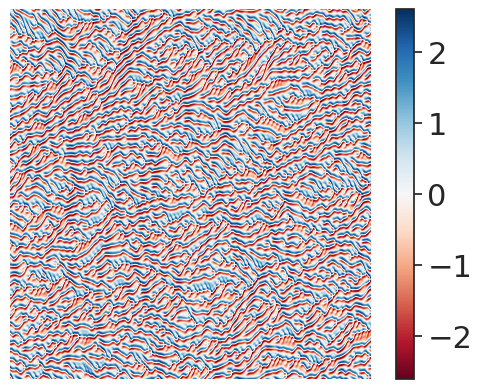

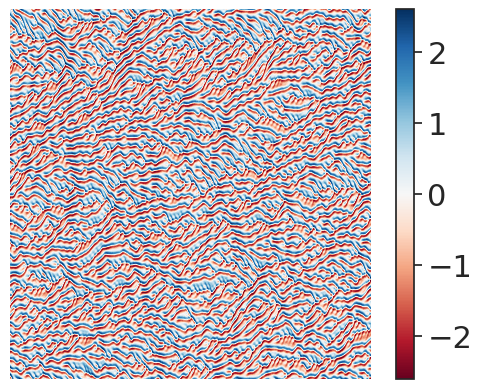

In [16]:
to_plot = [
    (('_true', 'TrueState'), dict(trajectory=true_state)),
    *cfgs.items(),
]
v_min = None
v_max = None
for _, v in to_plot:
    _v_min = np.quantile(v['trajectory'], .01)
    _v_max = np.quantile(v['trajectory'], .99)
    if v_min is None or v_min > _v_min:
        v_min = _v_min
    if v_max is None or v_max > _v_max:
        v_max = _v_max
for (alt_id, label), v in to_plot:
    fig_trajectory, ax = plt.subplots()
    traj = v['trajectory']
    # imshow_out = ax.imshow(traj, cmap='RdBu', vmin=v_min, vmax=v_max)
    v_minimax = max(map(abs, (v_min, v_max)))
    imshow_out = ax.imshow(traj, cmap='RdBu', vmin=-v_minimax, vmax=v_minimax)
    # imshow_out = ax.imshow(traj, cmap='RdBu', norm=matplotlib.colors.TwoSlopeNorm(vmin=v_min, vcenter=0, vmax=v_max))
    ax.set_xlabel(label)
    ax.set_axis_off()
    fig_trajectory.savefig(f'Trajectory.{label}.pdf', format='pdf', bbox_inches='tight', pad_inches=.03)
    fig_trajectory.colorbar(imshow_out, ax=ax)
    # ax.remove()
    # fig_trajectory.savefig(f'Trajectory.colorbar.pdf', format='pdf', bbox_inches='tight', pad_inches=.03)

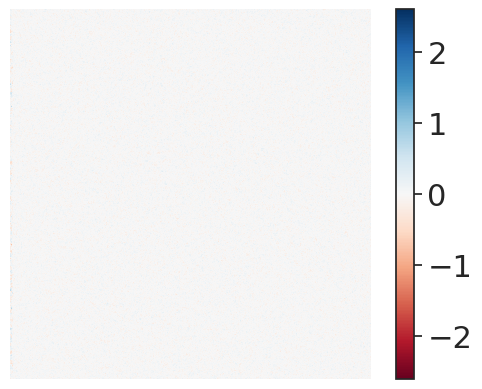

In [17]:
to_plot = [
    *cfgs.items(),
]
# v_min = None
# v_max = None
# for _, v in to_plot:
#     _v_min = np.quantile(v['trajectory'] - true_state, .01)
#     _v_max = np.quantile(v['trajectory'] - true_state, .99)
#     if v_min is None or v_min > _v_min:
#         v_min = _v_min
#     if v_max is None or v_max > _v_max:
#         v_max = _v_max
for (alt_id, label), v in to_plot:
    fig_error, ax = plt.subplots()
    traj = v['trajectory'] - true_state
    # imshow_out = ax.imshow(traj, cmap='RdBu', vmin=v_min, vmax=v_max)#, norm=matplotlib.colors.CenteredNorm())
    # v_minimax = max(map(abs, (v_min, v_max)))
    imshow_out = ax.imshow(traj, cmap='RdBu', vmin=-v_minimax, vmax=v_minimax)
    ax.set_xlabel(label)
    ax.set_axis_off()
    fig_error.savefig(f'Error.{label}.pdf', format='pdf', bbox_inches='tight', pad_inches=.03)
    fig_error.colorbar(imshow_out, ax=ax)

In [12]:
import matplotlib.colors